# Домашнее задание №3

**Цель:** добиться качества 0.9 на top-1 accuracy (и 0.98 на top-5) при ограничении **400к обучаемых параметров** на **уникальном** сабсете из [cоревнования на Kaggle](https://www.kaggle.com/competitions/dog-breed-identification/data)

Для выполнения нам понадобятся данные из соревнования по ссылке, **мы работаем только с частью "train"**

### Система оценки:

#### Подход к решению (макс 5 баллов):

**1 балл** - рассмотрено 1 решение по transfer learning одной модели, взяты стандартный transform / loss / optimizer  
**3 балла** - рассмотренно минимум 2 решения (разные модели / разная заморозка слоев / разный head) или присутсвуют 2-3 эксперимента с оптимизацией (шедуллинг, оптимайзер, необычные аугментации, игры с лоссом)  
**5 баллов** - рассмотренно минимум 2 решения (разные модели, разная заморозка слоев) + присутсвуют 2-3 эксперимента с оптимизацией (шедуллинг, оптимайзер, необычные аугментации, игры с лоссом)  
> Промежуточные оценки выставляются по широте экспериментов и доказательной базе к их применению

#### Качество решения на тестовой выборке (макс 5 баллов), накопительная система:
**+ 3 балла** за превышение 0.9 на top-1 accuracy  
**+ 2 балла** за превышение 0.98 на top-3 accuracy
> Может быть накинуты баллы даже при отсутсвии метрик выше за доказательство недостижимости метрики на конкретном датасете (все переборы не проверялись)

**! Дополнительным баллом можно поощрить оригинальность и проработанность решения**

## 1. Необходимые импорты и вспомогательные функции

In [122]:
import pandas as pd
import torch
import random
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models, datasets
from torch.utils.data import Dataset, DataLoader
from PIL import Image

%matplotlib inline

In [123]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [124]:
def set_seed_to_all(seed: int) -> None:
    """
    Проставить всему сид. 
    Важно: не влияет на детерменированность обучения.
    """
    # Python
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Python hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)


def train_test_val_split(df: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Деление данных на трейн/тест/валидацию.
    """
    # Train vs valtest
    train_df, temp_df = train_test_split(
        df,
        test_size=0.3,
        stratify=df["breed"],
        random_state=seed
    )
    
    # Val vs test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df["breed"],
        random_state=seed
    )

    print("Train:", len(train_df))
    print("Val:", len(val_df))
    print("Test:", len(test_df))
    return train_df, val_df, test_df


def plot_distribution(df: pd.DataFrame, title: str) -> None:
    """
    Отрисовка классов.
    """
    counts = df["breed"].value_counts().sort_values(ascending=False)
    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Breed")
    plt.ylabel("Number of images")
    plt.xticks(rotation=90)
    plt.tight_layout()


class DogDataset(Dataset):
    """
    Вариант датасета.
    """
    def __init__(
        self,
        df: pd.DataFrame,
        images_dir: str = "dog-breed-identification/train",
        images_ext = ".jpg",
        transform: transforms.Compose | None = None,
        class_to_idx: dict[str, int] | None = None
    ) -> None:
        self.df = df
        self.transform = transform
        self.images_dir = images_dir
        self.images_ext = images_ext

        if class_to_idx is None:
            classes = sorted(df["breed"].unique())
            self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        else:
            self.class_to_idx = class_to_idx

        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self) -> None:
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.df.iloc[idx]

        img_path = os.path.join(self.images_dir, row["id"] + self.images_ext)
        label_str = row["breed"]
        label = self.class_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


@torch.no_grad()
def evaluate_topk_with_time(
    model: nn.Module,
    dataloader: DataLoader,
    device: str | torch.device,
    k: tuple[int, ...] = (1, 3)
) -> dict[str, float]:
    """
    Целевая метрика.
    """
    model.eval()
    correct = {kk: 0 for kk in k}
    total = 0

    start = time.time()

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, pred = outputs.topk(max(k), dim=1)

        total += labels.size(0)

        for kk in k:
            correct_k = (pred[:, :kk] == labels.unsqueeze(1)).any(dim=1).sum().item()
            correct[kk] += correct_k

    elapsed = time.time() - start
    results = {f"top{kk}": correct[kk] / total for kk in k}
    results["inference_time_sec"] = elapsed
    results["samples_per_sec"] = total / elapsed

    return results

## 2. Создание УНИКАЛЬНОГО датасета

In [125]:
DATE_OF_BIRTH: int =  17 
MONTH_OF_BIRTH: int = 4
HEIGHT =  181
LASTNAME =  "Kalitsov"

# Получем сид по формуле
seed = (DATE_OF_BIRTH + MONTH_OF_BIRTH) * (ord(LASTNAME[0])%(HEIGHT%10))
set_seed_to_all(seed)

In [126]:
labels_df = pd.read_csv("dog-breed-identification/labels.csv")
label_names = list(set(labels_df.breed.values))
classes = random.sample(label_names, 20)
my_data = labels_df[labels_df["breed"].isin(classes)]

In [127]:
train_df, val_df, test_df = train_test_val_split(my_data, seed)

Train: 1209
Val: 259
Test: 260


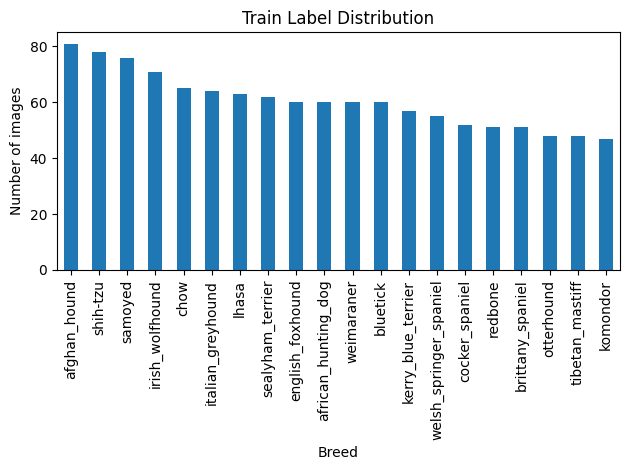

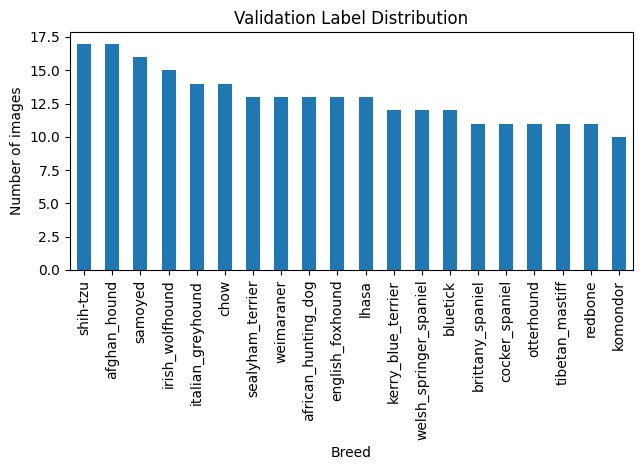

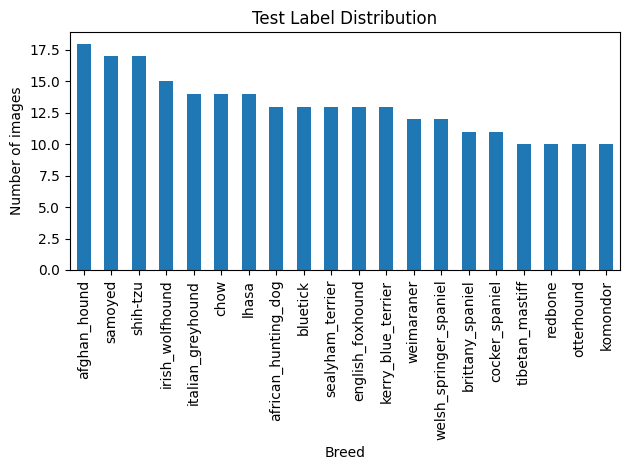

In [128]:
plot_distribution(train_df, "Train Label Distribution")
plot_distribution(val_df, "Validation Label Distribution")
plot_distribution(test_df, "Test Label Distribution")

## 3. Творческая часть

In [129]:
n_classes = len(classes)

In [130]:
## TODO: Грузим модель и издеваемся над ней

model = models.resnet50(weights="IMAGENET1K_V1")

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# заменить голову
model.fc = nn.Linear(2048, 20)
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_params < 400000, "Number of params must be less than 400.000"

In [131]:
import torchvision.transforms as T
## Создаем датасета, лоадеры, придумываем лосс и оптимиацию

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = DogDataset(train_df, transform=transform)
valid_dataset = DogDataset(val_df, transform=transform)
test_dataset = DogDataset(test_df, transform=transform)

# pin_memory=True позволяет не копировать cpu → pinned buffer (какой то промежуточный этап) → gpu
# а сразу в какой то buffer из которого можно сразу перекладывать на gpu.
train_loader = DataLoader(train_dataset, batch_size=64, pin_memory=True, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, pin_memory=True)

In [132]:
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

Функции для обучения и валидации я взял из домашки по NLP и подправил под эту.

In [133]:
from tqdm import tqdm
from IPython.display import clear_output
## Проводим итерации трейна

@torch.no_grad()
def validation_epoch(model, criterion, loader, max_steps_count = None, tqdm_desc="validate model"):
    loss_log = []
    acc_log = []
    model.eval()
    steps_count = min(max_steps_count, len(loader)) if max_steps_count else len(loader)

    for batch_id, (images, labels) in tqdm(enumerate(loader), total=steps_count, desc=tqdm_desc):
        if max_steps_count and batch_id >= max_steps_count:
            break

        images = images.to(device, non_blocking=True) # позволяет копировать на gpu ассинхронно
        labels = labels.to(device, non_blocking=True)
        pred = model(images)

        loss = criterion(pred, labels)
        loss_log.append(loss.item())

        acc = torch.sum(torch.argmax(pred, dim=1) == labels) / labels.shape[0]
        acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)


In [134]:
# max_batch_count для обучения не на полном датасете
def train_epoch(model, optimizer, criterion, loader, max_steps_count = None):
    model.train()
    steps_count = min(max_steps_count, len(loader)) if max_steps_count else len(loader)

    for batch_id, (images, labels) in tqdm(enumerate(loader), total=steps_count, desc="train"):
        if max_steps_count and batch_id >= max_steps_count:
            break

        optimizer.zero_grad()

        images = images.to(device, non_blocking=True) # позволяет копировать на gpu ассинхронно
        labels = labels.to(device, non_blocking=True)
        
        pred = model(images)
        loss = criterion(pred, labels)

        loss.backward()
        optimizer.step()

In [135]:
def plot_losses(train_losses, train_scores, val_losses, val_score):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_scores) + 1), train_scores, label='train')
    axs[1].plot(range(1, len(val_score) + 1), val_score, label='val')
    axs[1].set_ylabel('top1acc')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [136]:
def train(model, optimizer, criterion, scheduler=None, num_epochs = 10, num_batches_per_epoch = None):
    train_losses = []
    train_scores = []
    valid_losses = []
    valid_scores = []
    for epoch in range(num_epochs):
        train_epoch(model, optimizer, criterion, train_loader, num_batches_per_epoch)
        train_loss, train_score = validation_epoch(model, criterion, train_loader, tqdm_desc="train loss+acc")
        valid_loss, valid_score = validation_epoch(model, criterion, valid_loader, tqdm_desc="validation loss+acc")

        if scheduler:
            scheduler.step()

        train_losses.append(train_loss)
        train_scores.append(train_score)
        valid_losses.append(valid_loss)
        valid_scores.append(valid_score)
        
        plot_losses(train_losses, train_scores, valid_losses, valid_scores)
        print(f"Epoch {epoch+1}")
        print(f"Train loss: {train_loss:.4f}")
        print(f"Validation loss: {valid_loss:.4f}")
        print(f"train top1acc: {train_score:.2f}")
        print(f"validation top1acc: {valid_score:.2f}")

        if len(valid_scores) > 2 and valid_scores[-3] > valid_scores[-2] > valid_scores[-1]:
            print("Forced Stop")
            break

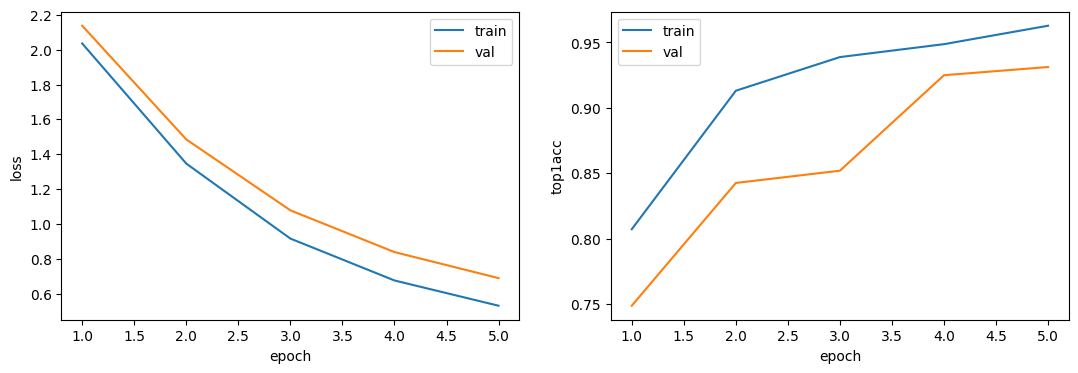

Epoch 5
Train loss: 0.5301
Validation loss: 0.6887
train top1acc: 0.96
validation top1acc: 0.93


In [137]:
train(model, optimizer, criterion, num_epochs = 5, num_batches_per_epoch = None)

## 4. Проверяем метрики и условия

In [138]:
result = evaluate_topk_with_time(model, test_loader, device)
assert trainable_params < 400000, "Number of params must be less than 400.000"
if result['top1'] > 0.9:
    print("Добились метрики на top-1")
if result['top3'] > 0.98:
    print("Добились метрики на top-3")
print("Резульат: ", result)

Добились метрики на top-1
Добились метрики на top-3
Резульат:  {'top1': 0.9384615384615385, 'top3': 0.9884615384615385, 'inference_time_sec': 1.328995943069458, 'samples_per_sec': 195.63641360672798}


Резнет пушка. Попробую с другим оптимайзером за такое же количество эпох сойтись к таким приятным результатам.

In [139]:
## Заново создаю модель

model = models.resnet50(weights="IMAGENET1K_V1")

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# заменить голову
model.fc = nn.Linear(2048, 20)
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_params < 400000, "Number of params must be less than 400.000"

optimizer = optim.SGD(model.parameters(), lr=3e-4)

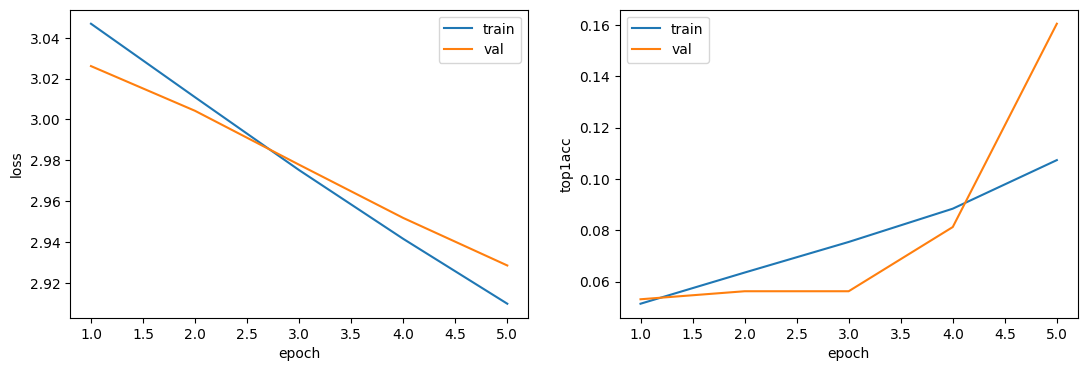

Epoch 5
Train loss: 2.9098
Validation loss: 2.9285
train top1acc: 0.11
validation top1acc: 0.16


In [140]:
train(model, optimizer, criterion, num_epochs = 5, num_batches_per_epoch = None)

16% accuracy вообще топчик) при том, что рандомная модель выбивает 5% на 20 классах. Попробую learning rate изменить, может не лучший сетап.

In [141]:
## Заново создаю модель

model = models.resnet50(weights="IMAGENET1K_V1")

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# заменить голову
model.fc = nn.Linear(2048, 20)
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_params < 400000, "Number of params must be less than 400.000"

optimizer = optim.SGD(model.parameters(), lr=3e-3)

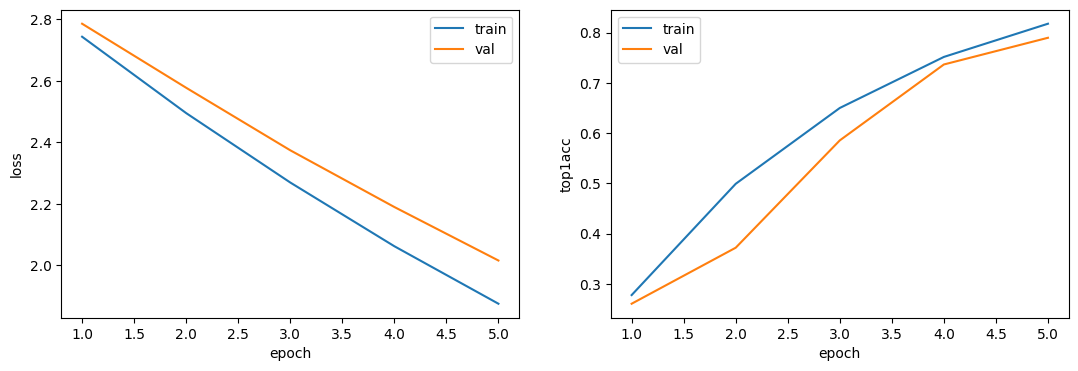

Epoch 5
Train loss: 1.8747
Validation loss: 2.0153
train top1acc: 0.82
validation top1acc: 0.79


In [142]:
train(model, optimizer, criterion, num_epochs = 5, num_batches_per_epoch = None)

Так куда лучше, но до Adam-а конечно не дотянул за тоже количество эпох. Попробую шедулер у SGD настроить, может ему поможет. Попробую косинусный.

In [143]:
## Заново создаю модель

model = models.resnet50(weights="IMAGENET1K_V1")

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# заменить голову
model.fc = nn.Linear(2048, 20)
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_params < 400000, "Number of params must be less than 400.000"

n_epochs = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=n_epochs
)

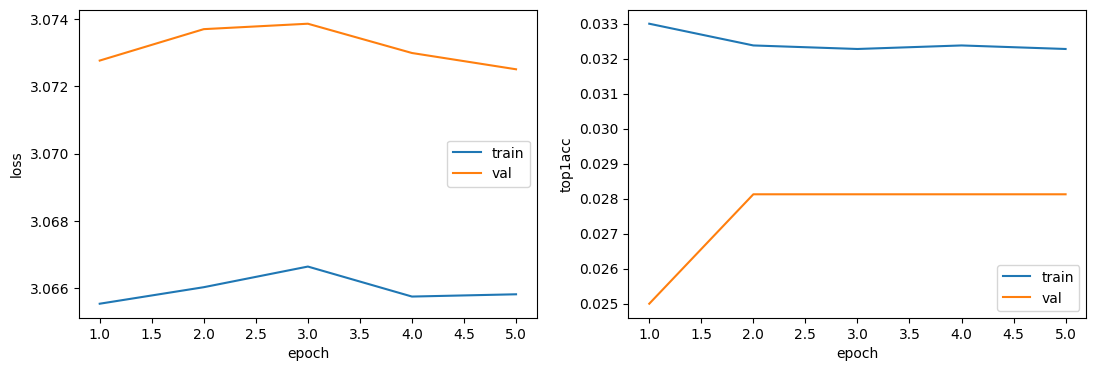

Epoch 5
Train loss: 3.0658
Validation loss: 3.0725
train top1acc: 0.03
validation top1acc: 0.03


In [ ]:
train(model, optimizer, criterion, scheduler, num_epochs = n_epochs, num_batches_per_epoch = None)

Опять не учится... Попробую опять lr подобрать, чтоб с шедулером училось.

In [150]:
## Заново создаю модель

model = models.resnet50(weights="IMAGENET1K_V1")

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# заменить голову
model.fc = nn.Linear(2048, 20)
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_params < 400000, "Number of params must be less than 400.000"

optimizer = optim.SGD(model.parameters(), lr=3e-2)

n_epochs = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=n_epochs
)


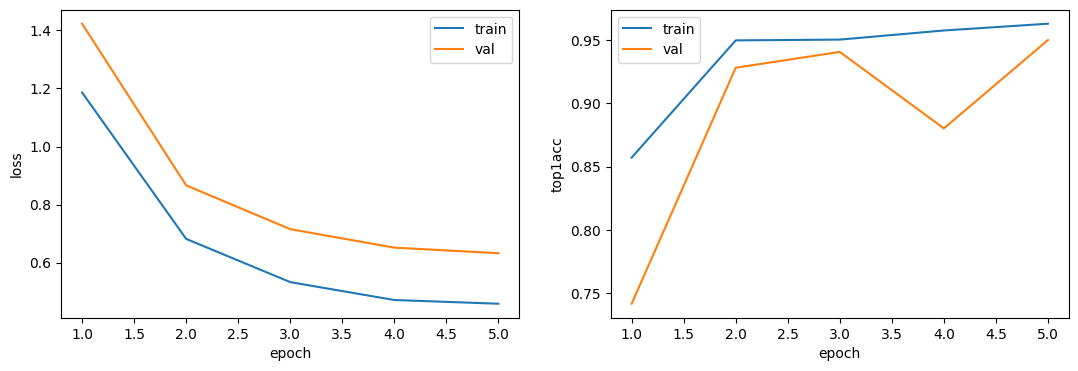

Epoch 5
Train loss: 0.4588
Validation loss: 0.6327
train top1acc: 0.96
validation top1acc: 0.95


In [151]:
train(model, optimizer, criterion, scheduler, num_epochs = n_epochs, num_batches_per_epoch = None)

In [152]:
result = evaluate_topk_with_time(model, test_loader, device)
assert trainable_params < 400000, "Number of params must be less than 400.000"
if result['top1'] > 0.9:
    print("Добились метрики на top-1")
if result['top3'] > 0.98:
    print("Добились метрики на top-3")
print("Резульат: ", result)

Добились метрики на top-1
Добились метрики на top-3
Резульат:  {'top1': 0.9307692307692308, 'top3': 0.9923076923076923, 'inference_time_sec': 1.6936569213867188, 'samples_per_sec': 153.51397128712426}


Ну вот, вообще топчик, побили Adam.

Попробую обучить другую архитектуру, к примеру MobileNet (тоже пока transfer learning).

In [183]:
## Заново создаю модель

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# уменьшу classifier, а то classifier + bottleneck-блок не помещаются в 400k параметров.
# хочу потом сравнить с fine-tuning, чтоб одна и та же модель была
model.classifier = nn.Sequential(
    nn.Linear(576, 512, bias=True),
    nn.Hardswish(),
    nn.Dropout(0.2),
    nn.Linear(512, 20, bias=True)
)

# разморозить classifier
for p in model.classifier.parameters():
    p.requires_grad = True

model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
assert trainable_params < 400000, "Number of params must be less than 400.000"

305684


In [184]:
# вернём Adam
optimizer = optim.Adam(model.parameters(), lr=3e-4)

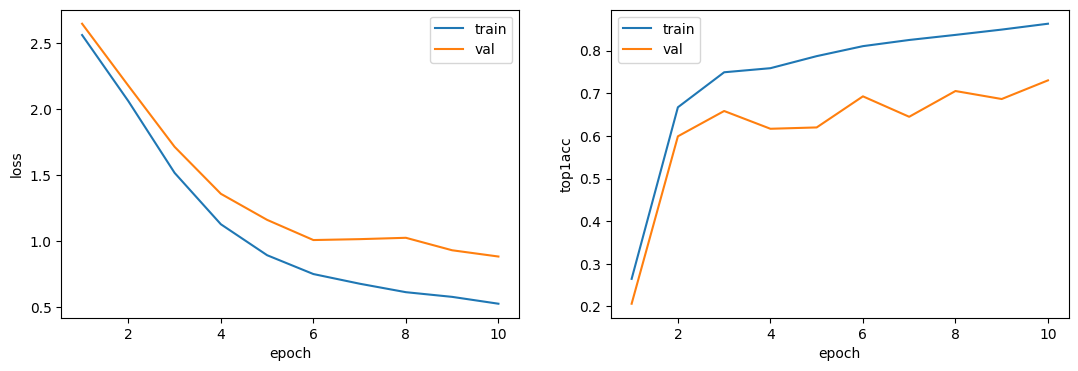

Epoch 10
Train loss: 0.5239
Validation loss: 0.8815
train top1acc: 0.86
validation top1acc: 0.73


In [185]:
train(model, optimizer, criterion, scheduler, num_epochs = 10, num_batches_per_epoch = None)

Она в 10 раз меньше резнета, так что я дал ей 10 эпох на обучение. Даже при этом видно, что уже не особо качество не растёт. Но это даже хорошо, так как я хотел сравнить, даст ли улучшение разморозка некоторых слоёв до классификации. Попробуем fine-tuning вместо transfer learning.

In [189]:
## Заново создаю модель

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# уменьшу classifier, а то classifier + bottleneck-блок не помещаются в 400k параметров.
# хочу потом сравнить с fine-tuning, чтоб одна и та же модель была
model.classifier = nn.Sequential(
    nn.Linear(576, 512, bias=True),
    nn.Hardswish(),
    nn.Dropout(0.2),
    nn.Linear(512, 20, bias=True)
)

# разморозить classifier
for p in model.classifier.parameters():
    p.requires_grad = True

# разморозить последний блок backbone
for p in model.features[-1].parameters():
    p.requires_grad = True

model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
assert trainable_params < 400000, "Number of params must be less than 400.000"

362132


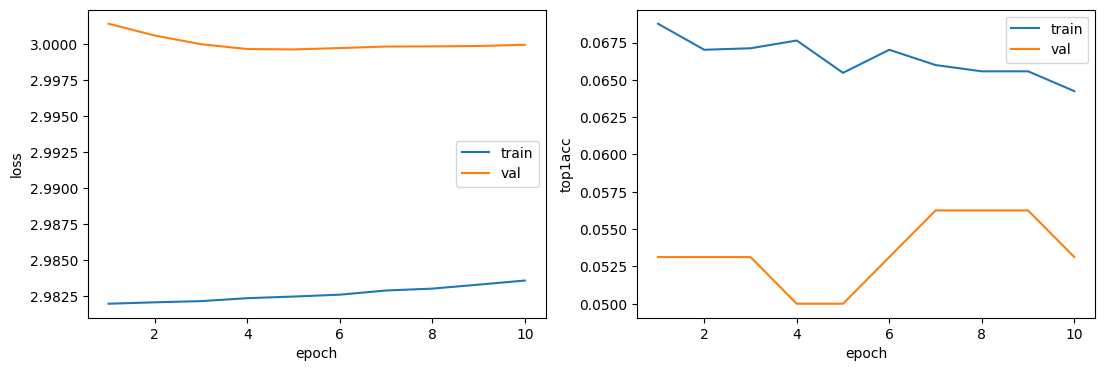

Epoch 10
Train loss: 2.9836
Validation loss: 2.9999
train top1acc: 0.06
validation top1acc: 0.05


In [190]:
train(model, optimizer, criterion, num_epochs = 10, num_batches_per_epoch = None)

Что то оно перестало учиться( Попробую learning rate другой.

In [197]:
## Заново создаю модель

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# заморозить всё
for p in model.parameters():
    p.requires_grad = False

# уменьшу classifier, а то classifier + bottleneck-блок не помещаются в 400k параметров.
# хочу потом сравнить с fine-tuning, чтоб одна и та же модель была
model.classifier = nn.Sequential(
    nn.Linear(576, 512, bias=True),
    nn.Hardswish(),
    nn.Dropout(0.2),
    nn.Linear(512, 20, bias=True)
)

# разморозить classifier
for p in model.classifier.parameters():
    p.requires_grad = True

# разморозить последний блок backbone
for p in model.features[-1].parameters():
    p.requires_grad = True

model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
assert trainable_params < 400000, "Number of params must be less than 400.000"

362132


In [199]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

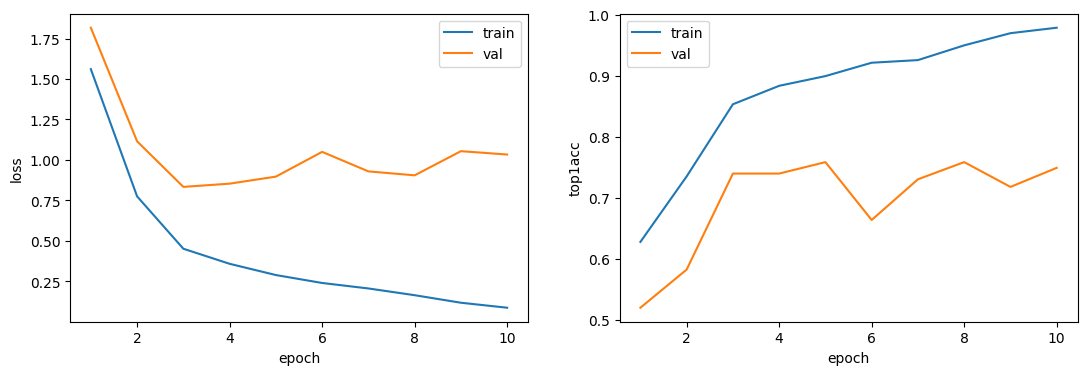

Epoch 10
Train loss: 0.0869
Validation loss: 1.0333
train top1acc: 0.98
validation top1acc: 0.75


In [200]:
train(model, optimizer, criterion, num_epochs = 10, num_batches_per_epoch = None)

Судя по графикам схватили смачное переобучение, но в целом по валидации чуть лучше, чем у варианта с обучением только классификатора.

Классная домашка, приятно, что всё учится в пределах минуты, спасибо.